# Michaelis-Menten シミュレーション & フィッティング

酵素反応をモンテカルロシミュレーション（`MMSim`）で生成し、
Michaelis-Menten 式（`MMFit`）を `scipy.optimize.curve_fit` でフィットする。

## 1. インポート

In [ ]:
import platform
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib

# OSごとにフォントを設定
_font = {'Darwin': 'Hiragino Sans', 'Windows': 'Yu Gothic', 'Linux': 'IPAexGothic'}
matplotlib.rcParams['font.family'] = _font.get(platform.system(), 'sans-serif')

## 2. モンテカルロシミュレーション関数

各タイムステップで乱数 $r \in (0,1)$ を生成し、酵素状態（遊離 / ES複合体）を遷移させる。

| 状態 | 遷移条件 | 遷移先 |
|------|---------|-------|
| 遊離酵素 | $r < p_s = 1-e^{-p_1 s}$ | ES複合体 |
| ES複合体 | $r > p_4 = 1-p_2-p_3$ | 解離（生成物あり: $p_3$、なし: $p_2$）|

返り値：$v = \text{生成物数} / t_m$

In [ ]:
def MMSim(s, p1, p2, p3, tm):
    """酵素反応モンテカルロシミュレーション（Michaelis-Menten）。

    Parameters
    ----------
    s  : 基質濃度
    p1 : 酵素-基質結合速度パラメータ  (ps = 1 - exp(-p1*s))
    p2 : ES複合体の生成物なし解離確率
    p3 : ES複合体の生成物あり解離確率 (kcat に相当)
    tm : シミュレーションステップ数
    """
    tm = int(tm)
    p4 = 1.0 - p2 - p3              # ES複合体が次ステップも維持される確率
    ps = 1.0 - np.exp(-p1 * s)      # 遊離酵素が基質と結合する確率

    r_arr = np.random.random(tm)
    es = 0   # 酵素状態: 0=遊離, 1=ES複合体
    p  = 0   # 生成物カウンタ

    for r in r_arr:
        if es:
            if r > p4:             # ES複合体が解離
                es = 0
                if r < p4 + p3:    # 生成物が生成 (p4 < r < p4+p3)
                    p += 1
        else:
            if r < ps:             # 酵素が基質と結合してES複合体へ
                es = 1

    return p / tm

## 3. Michaelis Menten 式フィッティング関数

$$v = \frac{V_{\max} s}{K_m + s}$$

In [ ]:
def MMFit(s, vmax, km):
    return vmax * s / (km + s)

## 4. シミュレーションパラメータ

In [5]:
p1 = 0.02   # 結合速度パラメータ
p2 = 0.01   # ES解離確率（生成物なし）
p3 = 0.08   # ES解離確率（生成物あり、kcat に相当）
tm = 10000  # シミュレーションステップ数

## 5. データ生成（モンテカルロ）

In [ ]:
s_data = np.arange(31, dtype=float)                             # 基質濃度 0, 1, 2, ..., 30
v_data = np.array([MMSim(s, p1, p2, p3, tm) for s in s_data])   # 反応速度
print("s :", s_data)
print("v :", v_data)

s : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
v : [0.     0.0158 0.0244 0.0314 0.0374 0.0387 0.0457 0.047  0.0528 0.049
 0.051  0.0579 0.0571 0.0592 0.0591 0.0586 0.0587 0.0623 0.062  0.0613
 0.0649 0.0641 0.0644 0.0635 0.066  0.0677 0.0686 0.0645 0.0681 0.0636
 0.068 ]


## 6. curve_fit でフィッティング

In [ ]:
vm0 = v_data.max() * 1.5                                            # 初期値 Vmax
km0 = float(s_data[np.argmin(np.abs(v_data - v_data.max() / 2))])   # 初期値 Km

popt, pcov = curve_fit(MMFit, s_data, v_data, p0=[vm0, km0])    # ミカエリスメンテン式へのフィッティング
perr = np.sqrt(np.diag(pcov))                                   # フィッティングパラメータの標準誤差
vmax_fit, km_fit = popt                                         # フィッティングパラメータの取得

rss = np.sum((v_data - MMFit(s_data, *popt)) ** 2)              # 残差平方和の計算

print(f"Vmax = {vmax_fit:.6f}  ± {perr[0]:.6f}")
print(f"Km   = {km_fit:.6f}  ± {perr[1]:.6f}")
print(f"残差平方和 = {rss:.4e}")

Vmax = 0.077151  ± 0.000986
Km   = 4.363241  ± 0.227408
残差平方和 = 8.4937e-05


## 7. プロット

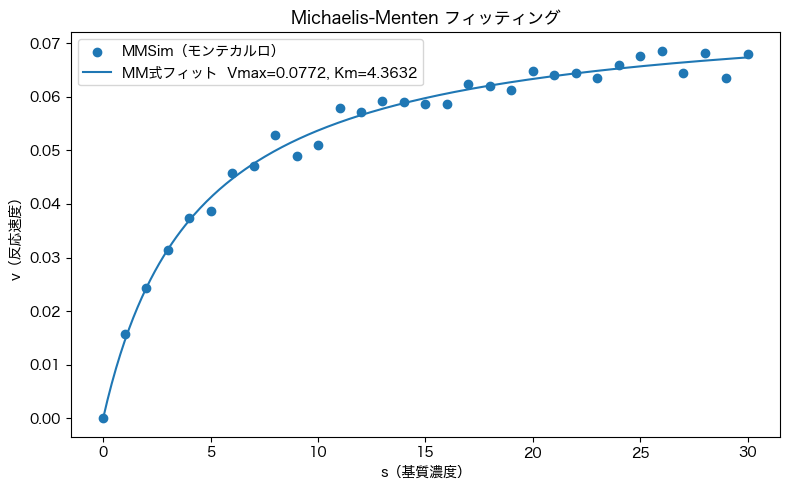

In [11]:
s_fine = np.linspace(0, 30, 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(s_data, v_data, zorder=5, label="MMSim（モンテカルロ）")
ax.plot(
    s_fine,
    MMFit(s_fine, *popt),
    label=f"MM式フィット  Vmax={vmax_fit:.4f}, Km={km_fit:.4f}",
)
ax.set_xlabel("s（基質濃度）")
ax.set_ylabel("v（反応速度）")
ax.set_title("Michaelis-Menten フィッティング")
ax.legend()
fig.tight_layout()
plt.show()